# Button-press-v3 Checkpoint Evaluation Visualization


In [ ]:
from pathlib import Path
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Change this if your notebook is not inside C:/Users/Michalis/Desktop/button_press_v3
ROOT = Path("button-press_v3_ppo_split_runs")
EVAL_DIR = ROOT / "results" / "checkpoint_eval"

summary_path = EVAL_DIR / "button_checkpoint_across_splits_summary.csv"
per_run_path = EVAL_DIR / "button_checkpoint_summary.csv"
raw_path = EVAL_DIR / "button_checkpoint_raw_episodes.csv"

print("Looking for:", summary_path)
assert summary_path.exists(), f"Missing file: {summary_path}"

summary = pd.read_csv(summary_path)
per_run = pd.read_csv(per_run_path) if per_run_path.exists() else None
raw = pd.read_csv(raw_path) if raw_path.exists() else None

summary.head()

Looking for: button-press_v3_ppo_split_runs\results\checkpoint_eval\button_checkpoint_across_splits_summary.csv


,config_name,checkpoint_step,group,mean_success_rate,std_success_rate,mean_return,std_return_across_splits,mean_first_success_step,std_first_success_step,n_runs
0,base_button,100000,test,1.0,0.0,61.089260,5.153636,37.866667,0.702377,3
1,base_button,100000,train,1.0,0.0,62.112793,3.934178,38.125926,0.265119,3
2,base_button,200000,test,1.0,0.0,73.762180,9.006449,38.933333,0.702377,3
3,base_button,200000,train,1.0,0.0,74.979632,4.700476,38.844444,0.365824,3
4,base_button,300000,test,1.0,0.0,67.635977,7.707699,38.333333,0.832666,3


## Quick overview

In [2]:
print("Configs:", sorted(summary["config_name"].unique()))
print("Checkpoints:", sorted(summary["checkpoint_step"].unique()))
print("Groups:", sorted(summary["group"].unique()))
print("Rows:", len(summary))

summary.sort_values(["config_name", "checkpoint_step", "group"]).head(20)

Configs: ['base_button', 'careful_button', 'light_entropy_button', 'short_rollout_button']
Checkpoints: [np.int64(100000), np.int64(200000), np.int64(300000), np.int64(400000), np.int64(500000)]
Groups: ['test', 'train']
Rows: 40


,config_name,checkpoint_step,group,mean_success_rate,std_success_rate,mean_return,std_return_across_splits,mean_first_success_step,std_first_success_step,n_runs
0,base_button,100000,test,1.000000,0.00000,61.089260,5.153636,37.866667,0.702377,3
1,base_button,100000,train,1.000000,0.00000,62.112793,3.934178,38.125926,0.265119,3
2,base_button,200000,test,1.000000,0.00000,73.762180,9.006449,38.933333,0.702377,3
3,base_button,200000,train,1.000000,0.00000,74.979632,4.700476,38.844444,0.365824,3
4,base_button,300000,test,1.000000,0.00000,67.635977,7.707699,38.333333,0.832666,3
5,base_button,300000,train,1.000000,0.00000,69.817866,6.462208,38.637037,0.179620,3
6,base_button,400000,test,1.000000,0.00000,76.313828,1.727262,39.000000,0.916515,3
7,base_button,400000,train,1.000000,0.00000,74.383181,7.883806,38.733333,0.322796,3
8,base_button,500000,test,1.000000,0.00000,79.581904,4.536308,38.933333,0.832666,3
9,base_button,500000,train,1.000000,0.00000,78.551234,7.683725,38.962963,0.336528,3


## Success rate over checkpoints

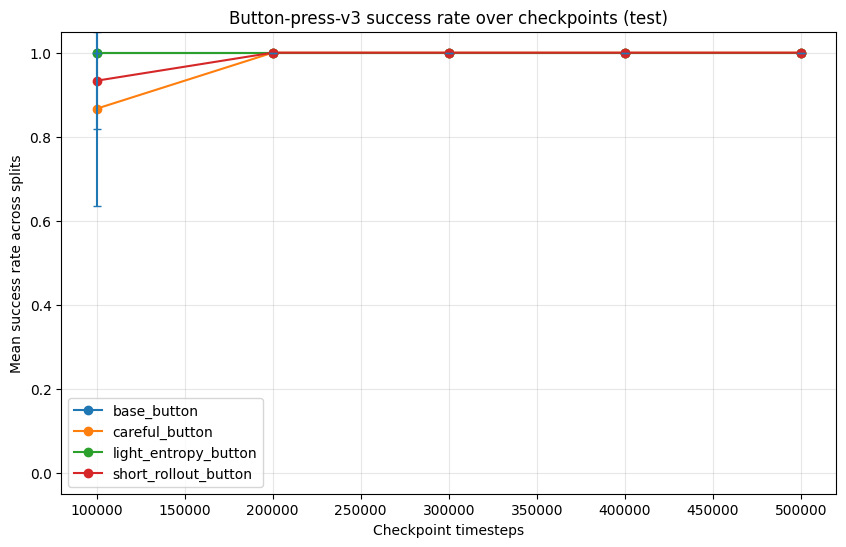

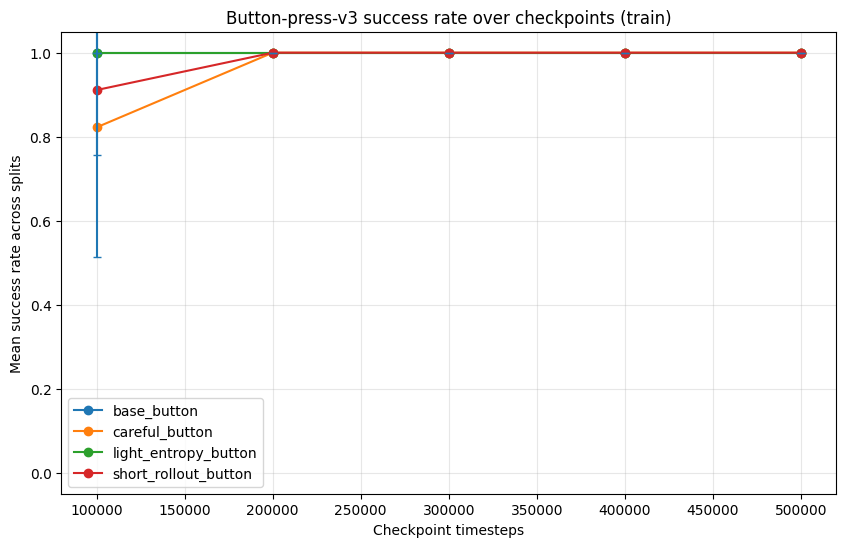

In [3]:
for group_name in sorted(summary["group"].unique()):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = summary[summary["group"] == group_name]
    
    for config in sorted(data["config_name"].unique()):
        d = data[data["config_name"] == config].sort_values("checkpoint_step")
        ax.plot(
            d["checkpoint_step"],
            d["mean_success_rate"],
            marker="o",
            label=config,
        )
        # Error bars show std across splits
        ax.errorbar(
            d["checkpoint_step"],
            d["mean_success_rate"],
            yerr=d["std_success_rate"].fillna(0),
            fmt="none",
            capsize=3,
        )
    
    ax.set_title(f"Button-press-v3 success rate over checkpoints ({group_name})")
    ax.set_xlabel("Checkpoint timesteps")
    ax.set_ylabel("Mean success rate across splits")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## First success step over checkpoints

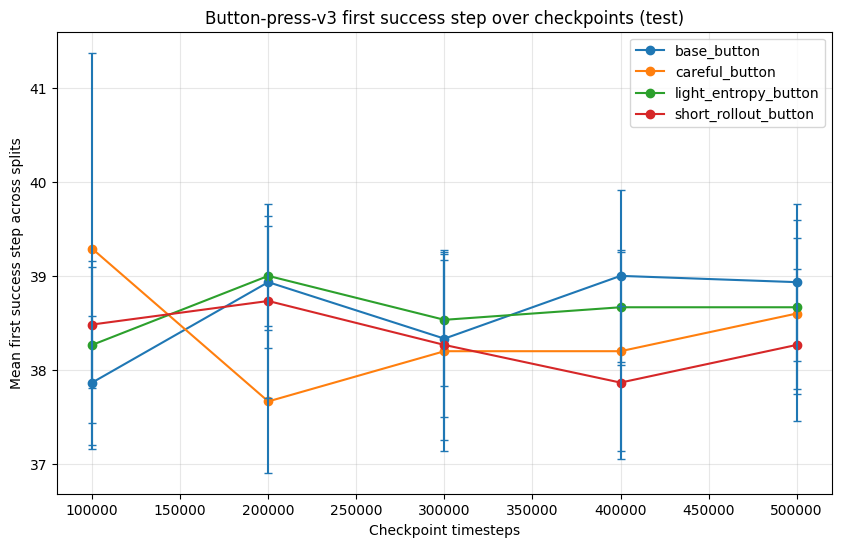

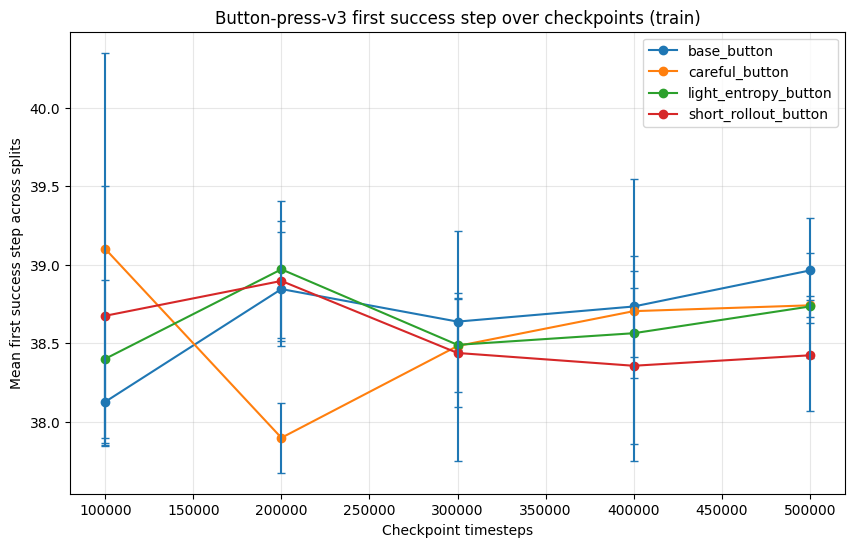

In [4]:
for group_name in sorted(summary["group"].unique()):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = summary[summary["group"] == group_name]
    
    for config in sorted(data["config_name"].unique()):
        d = data[data["config_name"] == config].sort_values("checkpoint_step")
        ax.plot(
            d["checkpoint_step"],
            d["mean_first_success_step"],
            marker="o",
            label=config,
        )
        ax.errorbar(
            d["checkpoint_step"],
            d["mean_first_success_step"],
            yerr=d["std_first_success_step"].fillna(0),
            fmt="none",
            capsize=3,
        )
    
    ax.set_title(f"Button-press-v3 first success step over checkpoints ({group_name})")
    ax.set_xlabel("Checkpoint timesteps")
    ax.set_ylabel("Mean first success step across splits")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## Average return over checkpoints


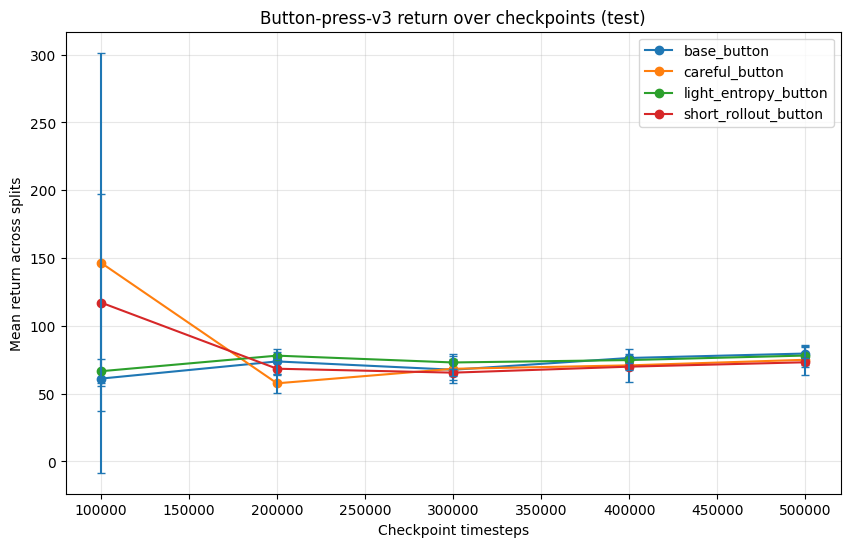

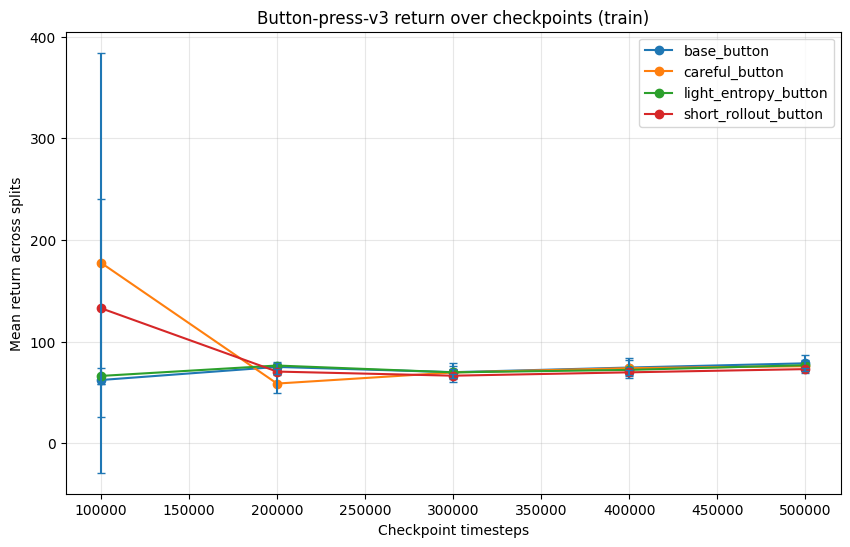

In [5]:
for group_name in sorted(summary["group"].unique()):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = summary[summary["group"] == group_name]
    
    for config in sorted(data["config_name"].unique()):
        d = data[data["config_name"] == config].sort_values("checkpoint_step")
        ax.plot(
            d["checkpoint_step"],
            d["mean_return"],
            marker="o",
            label=config,
        )
        ax.errorbar(
            d["checkpoint_step"],
            d["mean_return"],
            yerr=d["std_return_across_splits"].fillna(0),
            fmt="none",
            capsize=3,
        )
    
    ax.set_title(f"Button-press-v3 return over checkpoints ({group_name})")
    ax.set_xlabel("Checkpoint timesteps")
    ax.set_ylabel("Mean return across splits")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## Train vs test comparison at each checkpoint

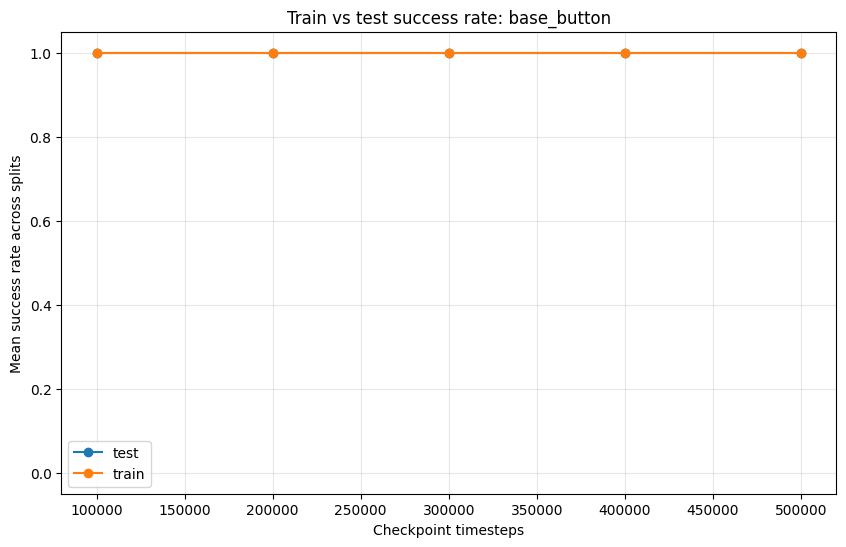

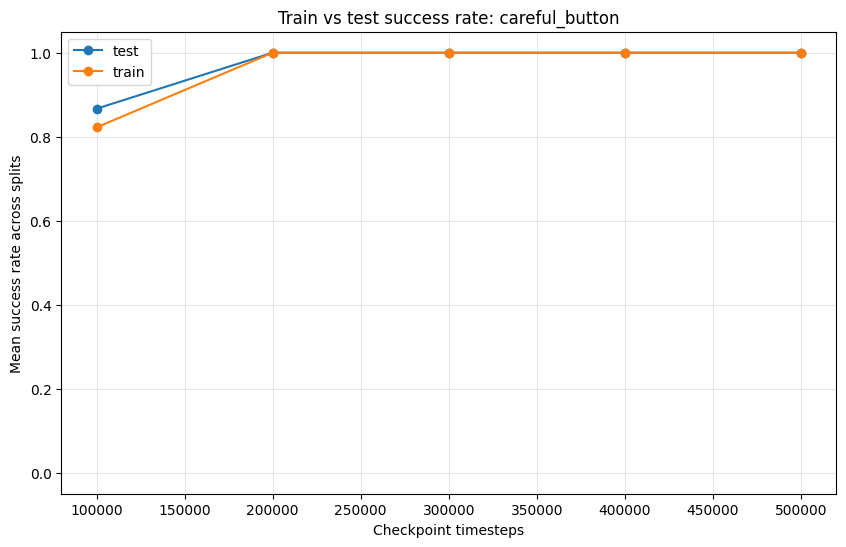

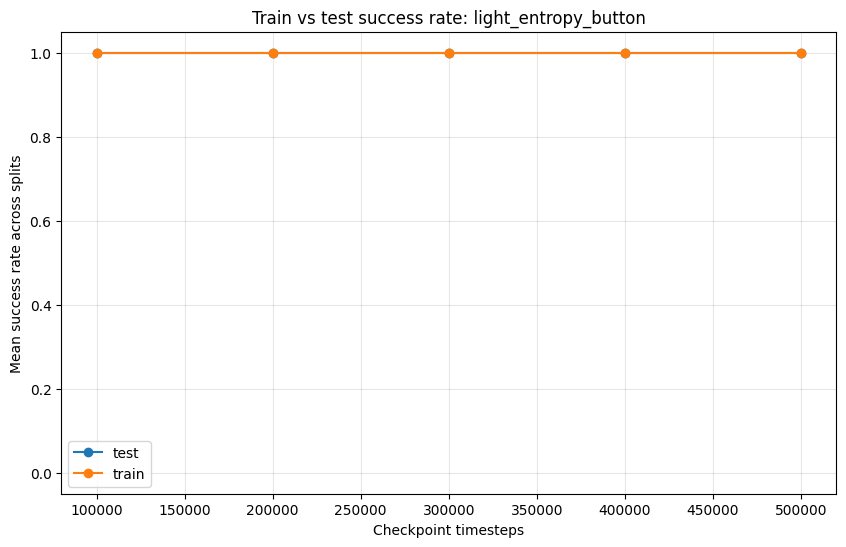

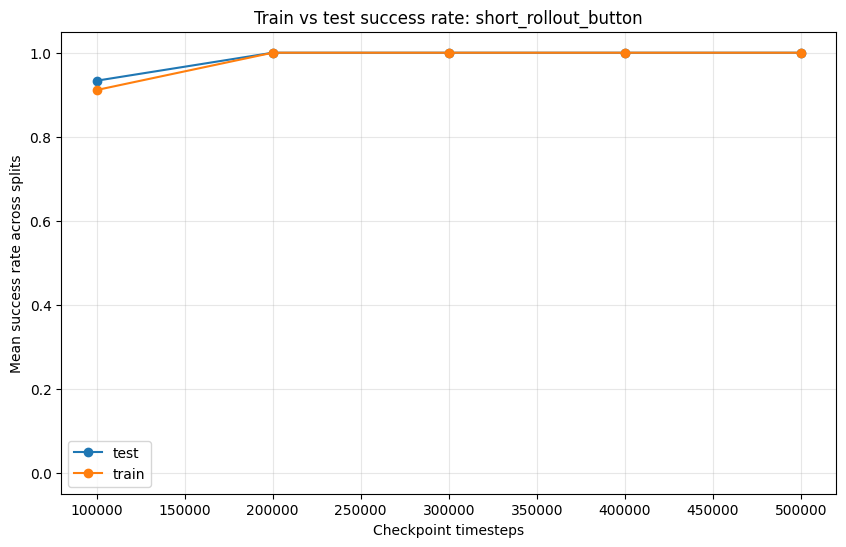

In [6]:
for config in sorted(summary["config_name"].unique()):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = summary[summary["config_name"] == config]
    
    for group_name in sorted(data["group"].unique()):
        d = data[data["group"] == group_name].sort_values("checkpoint_step")
        ax.plot(
            d["checkpoint_step"],
            d["mean_success_rate"],
            marker="o",
            label=group_name,
        )
    
    ax.set_title(f"Train vs test success rate: {config}")
    ax.set_xlabel("Checkpoint timesteps")
    ax.set_ylabel("Mean success rate across splits")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## Compact final tables

In [7]:
success_table = summary.pivot_table(
    index=["config_name", "checkpoint_step"],
    columns="group",
    values="mean_success_rate",
).reset_index()

first_success_table = summary.pivot_table(
    index=["config_name", "checkpoint_step"],
    columns="group",
    values="mean_first_success_step",
).reset_index()

print("Success rate table")
display(success_table)

print("First success step table")
display(first_success_table)

Success rate table


group,config_name,checkpoint_step,test,train
0,base_button,100000,1.000000,1.000000
1,base_button,200000,1.000000,1.000000
2,base_button,300000,1.000000,1.000000
3,base_button,400000,1.000000,1.000000
4,base_button,500000,1.000000,1.000000
5,careful_button,100000,0.866667,0.822222
6,careful_button,200000,1.000000,1.000000
7,careful_button,300000,1.000000,1.000000
8,careful_button,400000,1.000000,1.000000
9,careful_button,500000,1.000000,1.000000


First success step table


group,config_name,checkpoint_step,test,train
0,base_button,100000,37.866667,38.125926
1,base_button,200000,38.933333,38.844444
2,base_button,300000,38.333333,38.637037
3,base_button,400000,39.000000,38.733333
4,base_button,500000,38.933333,38.962963
5,careful_button,100000,39.288889,39.100529
6,careful_button,200000,37.666667,37.896296
7,careful_button,300000,38.200000,38.481481
8,careful_button,400000,38.200000,38.703704
9,careful_button,500000,38.600000,38.740741


## Best checkpoint per configuration

For success rate, many configs may tie at 1.0. In that case, use first-success-step as a secondary metric.

In [8]:
test_summary = summary[summary["group"] == "test"].copy()

# Sort by highest success rate, then lowest first success step
best = (
    test_summary.sort_values(
        ["config_name", "mean_success_rate", "mean_first_success_step"],
        ascending=[True, False, True],
    )
    .groupby("config_name")
    .head(1)
    [[
        "config_name",
        "checkpoint_step",
        "mean_success_rate",
        "std_success_rate",
        "mean_first_success_step",
        "mean_return",
        "n_runs",
    ]]
    .reset_index(drop=True)
)

best

,config_name,checkpoint_step,mean_success_rate,std_success_rate,mean_first_success_step,mean_return,n_runs
0,base_button,100000,1.0,0.0,37.866667,61.089260,3
1,careful_button,200000,1.0,0.0,37.666667,57.623597,3
2,light_entropy_button,100000,1.0,0.0,38.266667,66.537296,3
3,short_rollout_button,400000,1.0,0.0,37.866667,69.901759,3


## Save figures

This cell saves PNGs into:

```text
button-press_v3_ppo_split_runs/results/checkpoint_eval/figures
```

In [9]:
fig_dir = EVAL_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

def save_success_plot(group_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = summary[summary["group"] == group_name]
    for config in sorted(data["config_name"].unique()):
        d = data[data["config_name"] == config].sort_values("checkpoint_step")
        ax.plot(d["checkpoint_step"], d["mean_success_rate"], marker="o", label=config)
        ax.errorbar(d["checkpoint_step"], d["mean_success_rate"], yerr=d["std_success_rate"].fillna(0), fmt="none", capsize=3)
    ax.set_title(f"Button-press-v3 success rate over checkpoints ({group_name})")
    ax.set_xlabel("Checkpoint timesteps")
    ax.set_ylabel("Mean success rate across splits")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()
    out = fig_dir / f"button_checkpoint_success_rate_{group_name}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out

def save_first_success_plot(group_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = summary[summary["group"] == group_name]
    for config in sorted(data["config_name"].unique()):
        d = data[data["config_name"] == config].sort_values("checkpoint_step")
        ax.plot(d["checkpoint_step"], d["mean_first_success_step"], marker="o", label=config)
        ax.errorbar(d["checkpoint_step"], d["mean_first_success_step"], yerr=d["std_first_success_step"].fillna(0), fmt="none", capsize=3)
    ax.set_title(f"Button-press-v3 first success step over checkpoints ({group_name})")
    ax.set_xlabel("Checkpoint timesteps")
    ax.set_ylabel("Mean first success step across splits")
    ax.grid(True, alpha=0.3)
    ax.legend()
    out = fig_dir / f"button_checkpoint_first_success_step_{group_name}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.close(fig)
    return out

saved = []
for g in sorted(summary["group"].unique()):
    saved.append(save_success_plot(g))
    saved.append(save_first_success_plot(g))

for p in saved:
    print("Saved:", p)

Saved: button-press_v3_ppo_split_runs\results\checkpoint_eval\figures\button_checkpoint_success_rate_test.png
Saved: button-press_v3_ppo_split_runs\results\checkpoint_eval\figures\button_checkpoint_first_success_step_test.png
Saved: button-press_v3_ppo_split_runs\results\checkpoint_eval\figures\button_checkpoint_success_rate_train.png
Saved: button-press_v3_ppo_split_runs\results\checkpoint_eval\figures\button_checkpoint_first_success_step_train.png
